## Settings

In [640]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [641]:
## libraries
import sys
import pandas as pd
from pathlib import Path
from IPython.display import Markdown, display

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.data.builders import load_processed_data
from src.estimators.factories import load_estimators
from src.evaluators.metrics import spec_marginal_delta
from src.evaluators.decomposing import (
    train_decomposed_separation,
    train_decomposed_attribution,
    compile_decomposed_separation,
    compile_decomposed_attribution,
    stat_decomposed_summary,
    stat_decomposed_attribution,
    stat_decomposed_test,
)
from src.evaluators.tables import main_table
from src.visualizers.visualizing import plot_decomposition_evidence

## constants
from src.evaluators.metrics import (
    FRONTIER_METRICS,
    CONSENSUS_METRICS
)
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z,
    TARGET,
)

## Initialization

In [642]:
## reproducibility
N_DECIMALS = 2
RANDOM_STATE = 42
N_REPEATS = 30

## load data and models
data = load_processed_data()
models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Learned Models: 9 estimators


## Training

In [643]:
## train decomposed separation
cached_decomposed_separation = globals().get("results_dict_decomposed_separation")
if (
    not isinstance(cached_decomposed_separation, dict)
    or cached_decomposed_separation.get("n_repeats") != N_REPEATS
    or cached_decomposed_separation.get("random_state") != RANDOM_STATE
):
    results_dict_decomposed_separation = train_decomposed_separation(
        data = data,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

In [644]:
## train decomposed residual attribution
cached_decomposed_attribution = globals().get("results_dict_decomposed_attribution")
if (
    not isinstance(cached_decomposed_attribution, dict)
    or cached_decomposed_attribution.get("n_repeats") != N_REPEATS
    or cached_decomposed_attribution.get("random_state") != RANDOM_STATE
):
    results_dict_decomposed_attribution = train_decomposed_attribution(
        data = data,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

## Post-Processing

In [645]:
## compile decomposed separation results
results_decomposed_separation, predictions_decomposed_separation = compile_decomposed_separation(
    results = results_dict_decomposed_separation
)

## compile decomposed residual attribution results
results_decomposed_attribution, predictions_decomposed_attribution = compile_decomposed_attribution(
    results = results_dict_decomposed_attribution
)

## Residual Attribution Test
The residual attribution test probes whether, after estimating the capacity stage $C(X)$, the remaining slack is better predicted from dynamics than from topology. Under the additive decomposition $y^* = C(X) + R(Z)$, the residual slack $s = y^* - \hat{C}(X)$ should be more predictable from $Z$ than from $X$. Each contrast is evaluated with a paired one-sided Wilcoxon signed-rank statistic on domain-level mean absolute error (MAE).

- **$H_0$**: Topology predicts residual slack at least as well as dynamics ($\Delta \mathrm{MAE} \le 0$).
- **$H_1$**: Dynamics predict residual slack better than topology ($\Delta \mathrm{MAE} > 0$).

Rejecting $H_0$ establishes that residual slack is more predictably attributable to dynamics than to unrecovered topological information after conditioning on $C(X)$.

### Decomposition Protocol
Separate learners are fit for $X \to s$ and $Z \to s$ within repeated-seed LOGO-CV (domain) splits. Predictions are averaged across seeds, then aggregated to one MAE value per (model $\times$ domain) for each residual-input source.

### Empirical Test Specification
Paired differences are formed as $\Delta \mathrm{MAE} = \mathrm{MAE}_{X \to s} - \mathrm{MAE}_{Z \to s}$ on matched (model $\times$ domain) units. The table reports the paired median shift, rank-biserial effect size, and Holm-adjusted one-sided p-value summarizing whether the dynamics-based residual model consistently outperforms the topology-based residual model.

In [646]:
## one-sided wilcoxon test for residual attribution
results_attribution = stat_decomposed_attribution(
    predictions = predictions_decomposed_attribution,
    decimals = N_DECIMALS,
)

display(results_attribution)

Paired One-Sided Test (Wilcoxon Signed-Rank): n = 45
H₀: Δ MAE ≤ 0
H₁: Δ MAE > 0
Median Δ MAE: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, positive values favor Z -> slack
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Diff.: Yes if Holm-adj. p < 0.05 and Median Δ MAE > 0
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,,Median Δ MAE,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,Diff.
Property,Comparison,,,,,,
Residual Attribution,Topology vs Dynamics,0.65,0.52,0.00,0.00,**,Yes


_Residual slack is predicted more accurately from dynamics than from topology, with a positive median MAE shift and a significant one-sided Wilcoxon result. This means the additive decomposition is not splitting predictors into arbitrary blocks. After the capacity component $C(X)$ is removed, the remaining explainable variation aligns with dynamic information rather than leftover topological signal. The result supports a clear division: topology carries baseline capacity, and dynamics carry the residual structure that remains after capacity is accounted for._

## Parsimonious Sufficiency Tests
The parsimonious sufficiency tests probe whether the additive decomposition $C(X) + R(Z)$ is necessary and sufficient relative to both richer and simpler alternatives. Two performance dimensions are evaluated independently for each comparison group: the efficiency index (EI) measures frontier placement accuracy, and the consensus index (CI) measures rank-order agreement.

### Richer Specifications: Non-Inferiority
For richer alternatives — interaction-augmented residual, interaction-joint, and joint — the claim is that added complexity delivers no meaningful gain. Each richer spec is compared against additive with a paired one-sided Wilcoxon signed-rank statistic under an empirically derived margin $\delta$.

- **$H_0$**: The richer specification exceeds additive by at least $\delta$ ($\Delta \ge \delta$).
- **$H_1$**: The richer specification does not exceed additive by $\delta$ ($\Delta < \delta$).

Rejecting $H_0$ establishes that complexity fails to produce a practically meaningful improvement.

### Simpler Specifications: Inferiority
For simpler alternatives — capacity-only and dynamics-only — the claim is that removing one component incurs a meaningful loss. Each simpler spec is compared against additive with a paired one-sided Wilcoxon signed-rank statistic under the same empirically derived margin $\delta$.

- **$H_0$**: The paired gap is no worse than $-\delta$ ($\Delta \ge -\delta$).
- **$H_1$**: The paired gap falls below $-\delta$ ($\Delta < -\delta$).

Rejecting $H_0$ establishes that additive outperforms the reduced specification by a practically meaningful margin, supporting the necessity of each component.

### Decomposition Protocol
All specifications are fit under repeated-seed LOGO-CV (domain): additive $C(X) + R(Z)$, interaction-augmented residual, interaction-joint, joint, capacity-only, and dynamics-only. Predictions are averaged across seeds before scoring per (model $\times$ domain).

### Reporting Convention
The descriptive summary reports median `[IQR]` EI across matched (model $\times$ domain) units, with `VR`, `MV`, and `MS` included as auxiliary frontier diagnostics. This table provides the empirical scale for the tests below.

### Empirical Test Specification
The margin $\delta$ is set from the interquartile range of original values, anchoring the tests to natural variability under the reference specification. Paired gaps are formed as $\Delta = \text{score}_{\text{spec}} - \text{score}_{\text{additive}}$, and each table reports the median paired gap, rank-biserial effect size, Holm-adjusted one-sided p-value, and decision for each alternative specification.

In [647]:
## empirical delta for EI tests
delta_ei = spec_marginal_delta(
    results = results_decomposed_separation,
    feat_value = ["ei"],
    label_ref = "specification",
    value_ref = "additive",
    method = "iqr",
    scale = 1.0,  ## iqr range
    decimals = N_DECIMALS
)

## empirical delta for CI tests
delta_ci = spec_marginal_delta(
    results = results_decomposed_separation,
    feat_value = ["ci"],
    label_ref = "specification",
    value_ref = "additive",
    method = "iqr",
    scale = 1.0,  ## iqr range
    decimals = N_DECIMALS
)

In [648]:
## non-inferiority test: richer specifications on EI
results_complex_ei = stat_decomposed_test(
    results = results_decomposed_separation,
    delta = delta_ei,
    metric = "ei",
    specs = ("interaction", "interaction_joint", "joint"),
    direction = "noninferiority",
    decimals = N_DECIMALS)

display(results_complex_ei)

Paired Non-Inferiority Test (Wilcoxon Signed-Rank): n = 45, δ = 0.09, metric = EI
H₀: Δ EI ≤ -δ
H₁: Δ EI > -δ
NI.: Yes if Holm-adj. p < 0.05 and Median Δ EI > -δ
Median Δ EI: Median of paired differences (additive − spec)
Rank-biserial r: Paired effect size, positive values favor the tested direction
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,Median Δ EI,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,NI.
Specification,,,,,,
Interaction,-0.00,0.91,0.00,0.00,***,Yes
Interaction Joint,0.01,0.83,0.00,0.00,***,Yes
Joint,0.01,0.83,0.00,0.00,***,Yes


In [649]:
## non-inferiority test: complex specifications on CI
results_complex_ci = stat_decomposed_test(
    results = results_decomposed_separation,
    delta = delta_ci,
    metric = "ci",
    specs = ("interaction", "interaction_joint", "joint"),
    direction = "noninferiority",
    decimals = N_DECIMALS
)
display(results_complex_ci)

Paired Non-Inferiority Test (Wilcoxon Signed-Rank): n = 45, δ = 0.27, metric = CI
H₀: Δ CI ≤ -δ
H₁: Δ CI > -δ
NI.: Yes if Holm-adj. p < 0.05 and Median Δ CI > -δ
Median Δ CI: Median of paired differences (additive − spec)
Rank-biserial r: Paired effect size, positive values favor the tested direction
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,Median Δ CI,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,NI.
Specification,,,,,,
Interaction,0.01,1.00,0.00,0.00,***,Yes
Interaction Joint,0.19,0.99,0.00,0.00,***,Yes
Joint,0.21,0.98,0.00,0.00,***,Yes


In [671]:
## inferiority test: simple specifications on EI
results_simple_ei = stat_decomposed_test(
    results = results_decomposed_separation,
    delta = delta_ei,
    metric = "ei",
    specs = ("capacity_only", "dynamics_only"),
    direction = "inferiority",
    decimals = N_DECIMALS
)

display(results_simple_ei)

Paired Inferiority Test (Wilcoxon Signed-Rank): n = 45, δ = 0.09, metric = EI
H₀: Δ EI ≤ δ
H₁: Δ EI > δ
Inf.: Yes if Holm-adj. p < 0.05 and Median Δ EI > δ
Median Δ EI: Median of paired differences (additive − spec)
Rank-biserial r: Paired effect size, positive values favor the tested direction
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,Median Δ EI,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,Inf.
Specification,,,,,,
Capacity Only,0.01,-0.94,1.00,1.00,,No
Dynamics Only,0.00,-0.93,1.00,1.00,,No


In [672]:
## inferiority test: simple specifications on CI
results_simple_ci = stat_decomposed_test(
    results = results_decomposed_separation,
    delta = delta_ci,
    metric = "ci",
    specs = ("capacity_only", "dynamics_only"),
    direction = "inferiority",
    decimals = N_DECIMALS
)
display(results_simple_ci)

Paired Inferiority Test (Wilcoxon Signed-Rank): n = 45, δ = 0.27, metric = CI
H₀: Δ CI ≤ δ
H₁: Δ CI > δ
Inf.: Yes if Holm-adj. p < 0.05 and Median Δ CI > δ
Median Δ CI: Median of paired differences (additive − spec)
Rank-biserial r: Paired effect size, positive values favor the tested direction
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,Median Δ CI,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,Inf.
Specification,,,,,,
Capacity Only,0.36,0.34,0.02,0.05,*,Yes
Dynamics Only,0.18,0.19,0.14,0.14,,No


In [652]:
## median decomposition metrics by specification
decomposed_summary = stat_decomposed_summary(
    results = results_decomposed_separation,
    metric = "ei",
    decimals = N_DECIMALS
)

display(decomposed_summary)


,EI [IQR],VR,MV,MS
Specification,,,,
Additive,"0.78 [0.74, 0.82]",0.01,0.01,4.79
Interaction,"0.78 [0.73, 0.83]",0.00,0.00,5.27
Interaction Joint,"0.76 [0.74, 0.83]",0.00,0.00,5.60
Joint,"0.76 [0.74, 0.82]",0.00,0.00,4.86
Capacity Only,"0.76 [0.74, 0.80]",0.00,0.00,5.31
Dynamics Only,"0.77 [0.74, 0.83]",0.00,0.00,4.50


In [653]:
## median decomposition metrics by specification (CI)
decomposed_summary_ci = stat_decomposed_summary(
    results = results_decomposed_separation,
    metric = "ci",
    decimals = N_DECIMALS
)

display(decomposed_summary_ci)


,CI [IQR],RHO,RBO,DCR
Specification,,,,
Additive,"0.88 [0.68, 0.95]",0.7,0.91,0.84
Interaction,"0.78 [0.61, 0.92]",0.6,0.86,0.71
Interaction Joint,"0.65 [0.00, 0.86]",0.1,0.90,0.52
Joint,"0.65 [0.00, 0.85]",0.0,0.90,0.56
Capacity Only,"0.46 [0.00, 0.76]",0.0,0.91,0.50
Dynamics Only,"0.63 [0.00, 0.87]",0.1,0.90,0.55


_Richer specifications fail to deliver a practically meaningful improvement over the additive form on either EI or CI, establishing that added complexity is unnecessary. Simpler specifications — capacity-only and dynamics-only — fall below the additive form by at least $\delta$ on both metrics, establishing that each component is necessary. Together, these four tests support $C(X) + R(Z)$ as both sufficient against richer alternatives and necessary relative to reduced ones. Topology carries baseline capacity, dynamics carry the remaining structured variation, and neither component can be discarded without a meaningful and consistent performance penalty._

## Summary

In [ ]:
## manuscript summary table for decomposition validity

SPEC_LABELS = {
    "Capacity Only": "Capacity",
    "Dynamics Only": "Dynamics",
}

def _prep_spec_table(results: pd.DataFrame, category: str, decision_col: str) -> pd.DataFrame:
    frame = results.reset_index().copy()
    frame = frame.rename(columns = {"Specification": "Method", decision_col: "Decision"})
    frame["Method"] = frame["Method"].replace(SPEC_LABELS)
    frame["Specification"] = category
    return frame

## ei side (domain transfer)
summary_ei = pd.concat(
    objs = [
        _prep_spec_table(results = results_complex_ei, category = "Complex", decision_col = "NI."),
        _prep_spec_table(results = results_simple_ei, category = "Simple", decision_col = "Inf."),
    ],
    ignore_index = True,
)

## ci side (structural agreement)
summary_ci = pd.concat(
    objs = [
        _prep_spec_table(results = results_complex_ci, category = "Complex", decision_col = "NI."),
        _prep_spec_table(results = results_simple_ci, category = "Simple", decision_col = "Inf."),
    ],
    ignore_index = True,
)

display_table = main_table(
    results_left = summary_ei,
    results_right = summary_ci,
    index_feat = ["Specification", "Method"],
    value_feat_left = ["Median Δ EI", "Rank-biserial r", "Sig.", "Decision"],
    value_feat_right = ["Median Δ CI", "Rank-biserial r", "Sig.", "Decision"],
    header_left = "Domain Transfer",
    header_right = "Structural Agreement",
    short_feat_left = ["Δ EI", "r", "Sig.", "N/I"],
    short_feat_right = ["Δ CI", "r", "Sig.", "N/I"],
    row_order = [
        ("Complex", "Joint"),
        ("Complex", "Interaction"),
        ("Complex", "Interaction Joint"),
        ("Simple", "Capacity"),
        ("Simple", "Dynamics"),
    ],
)

display(display_table)
display(
    Markdown(
        "**Δ EI**, **Δ CI**: median paired difference between original log additive formulation and alternative specification performance, where positive values favor the original. "
        "**r**: rank-biserial correlation effect size, with positive values favoring the tested one-sided claim. "
        "**Sig.**: Holm-adjusted one-sided Wilcoxon *p* below threshold to test within each outcome "
        "(\*\*\* *p* < 0.001, \*\* *p* < 0.01, \* *p* < 0.05); significance supports the relevant sufficiency claim: "
        "for **Complex** methods, H₁: Δ > −δ, that original is non-inferior to the more complex method; "
        "for **Simple** methods, H₁: Δ > δ, that original outperforms the simpler method. "
        "**N/I**: non-inferiority supported for Complex methods or inferiority supported for Simple methods when Holm-adjusted *p* < 0.05 and median Δ satisfies the corresponding margin. "
        "Margin δ = IQR derived from natural variability in the original log additive formulation. "
        "Each test is conducted on *n* = 45 (9 models × 5 domains)."
    )
)

Domain Transfer                   \
                                           Δ EI      r Sig.  N/I   
Specification Method                                               
Complex       Joint                        0.01   0.83  ***  Yes   
              Interaction                 -0.00   0.91  ***  Yes   
              Interaction Joint            0.01   0.83  ***  Yes   
Simple        Capacity                     0.01  -0.94        No   
              Dynamics                     0.00  -0.93        No   

                                Structural Agreement                  
                                                Δ CI     r Sig.  N/I  
Specification Method                                                  
Complex       Joint                             0.21  0.98  ***  Yes  
              Interaction                       0.01  1.00  ***  Yes  
              Interaction Joint                 0.19  0.99  ***  Yes  
Simple        Capacity                          0.36  0.34    *  Yes  
              Dynamics                          0.18  0.19        No

**Δ EI**, **Δ CI**: median paired difference between additive and alternative-specification performance, computed as additive − method; positive values favor the additive baseline. **r**: rank-biserial correlation effect size, with positive values favoring the tested one-sided claim. **Sig.**: Holm-adjusted one-sided Wilcoxon *p* below threshold to test within each outcome (\*\*\* *p* < 0.001, \*\* *p* < 0.01, \* *p* < 0.05); significance supports the relevant sufficiency claim: for **Complex** methods, H₁: Δ > −δ, that additive is non-inferior to the richer method; for **Simple** methods, H₁: Δ > δ, that additive outperforms the reduced method. **N/I**: non-inferiority supported for Complex methods or inferiority supported for Simple methods when Holm-adjusted *p* < 0.05 and median Δ satisfies the corresponding margin. Margin δ = IQR derived from natural variability in the additive baseline. Each test is conducted on *n* = 45 (9 models × 5 domains).

_Decision rule: for **Complex** specifications, **Decision = non-inferiority (NI.)** relative to additive; for **Simple** specifications, **Decision = inferiority (Inf.)** relative to additive. A "Yes" indicates the corresponding one-sided claim is supported after Holm adjustment._

## Visualization

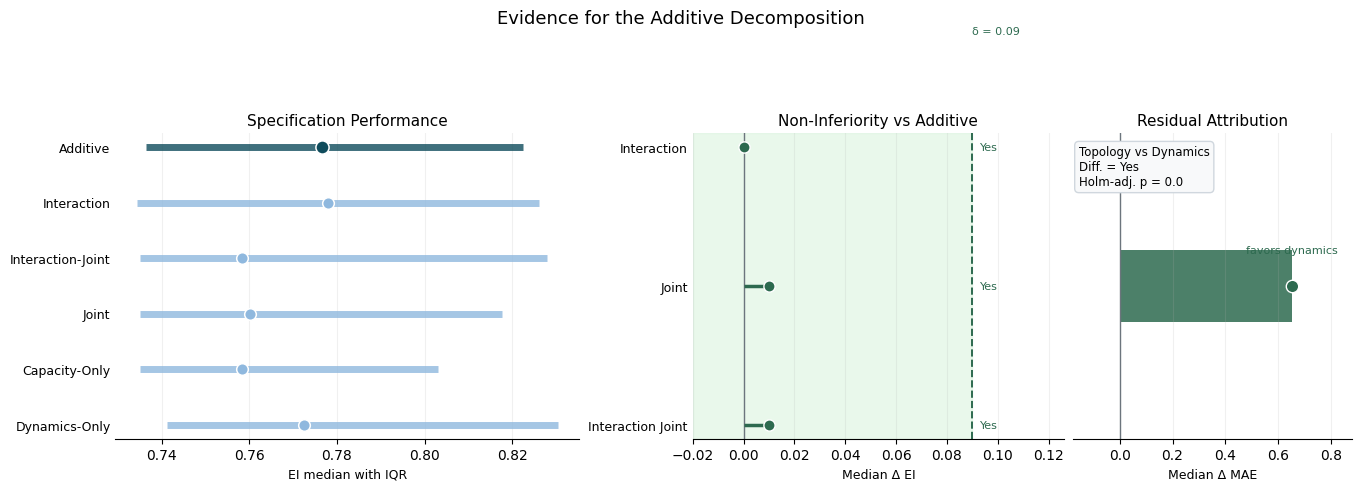

In [655]:
## decomposition evidence figure
fig, axes = plot_decomposition_evidence(
    results = results_decomposed_separation,
    noninferiority = results_complex_ei,
    attribution = results_attribution,
    delta = delta_ei,
    title = "Evidence for the Additive Decomposition",
)